In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("/Users/snehajuyal/SALES/SALES/data/cleaned_online_retail.csv")

In [3]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [4]:
df['InvoiceDate'].max()

Timestamp('2011-12-09 12:50:00')

In [5]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [8]:
df['TotalPrice'] = df['Quantity'] * df['Price']

rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalPrice': 'sum'
})


In [9]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [10]:
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,17,-64.68
12347.0,2,8,5633.32
12348.0,75,5,2019.40
12349.0,19,5,4404.54
12350.0,310,1,334.40


In [11]:
rfm.describe()

,Recency,Frequency,Monetary
count,5942.000000,5942.000000,5942.000000
mean,202.908617,7.552339,2801.799459
std,211.857936,15.972262,13973.922553
min,1.000000,1.000000,-25111.090000
25%,25.000000,2.000000,325.097500
50%,96.000000,4.000000,843.970000
75%,381.000000,8.000000,2182.005000
max,739.000000,510.000000,598215.220000


In [12]:
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    4,
    labels=[4,3,2,1]
)

In [13]:
rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    4,
    labels=[1,2,3,4]
)

In [14]:
rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    4,
    labels=[1,2,3,4]
)

In [15]:
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

In [21]:
def segment_customer(row):

    if row['RFM_Score'] == '444':
        return 'Champions'

    elif row['R_Score'] >= 3 and row['F_Score'] >= 3:
        return 'Loyal Customers'

    elif row['R_Score'] == 1:
        return 'At Risk'

    else:
        return 'Others'


In [22]:
rfm['Segment'] = rfm.apply(segment_customer, axis=1)

In [23]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
Customer ID,,,,,,,,
12346.0,326,17,-64.68,2,4,1,241,Others
12347.0,2,8,5633.32,4,3,4,434,Loyal Customers
12348.0,75,5,2019.40,3,3,3,333,Loyal Customers
12349.0,19,5,4404.54,4,3,4,434,Loyal Customers
12350.0,310,1,334.40,2,1,2,212,Others


In [24]:
rfm['Segment'].value_counts()

Segment
Others             2406
At Risk            1482
Loyal Customers    1388
Champions           666
Name: count, dtype: int64

In [25]:
segment_revenue = rfm.groupby('Segment')['Monetary'].sum()

In [26]:
segment_revenue

Segment
At Risk             802971.043
Champions          9346705.904
Loyal Customers    3819808.255
Others             2678807.186
Name: Monetary, dtype: float64

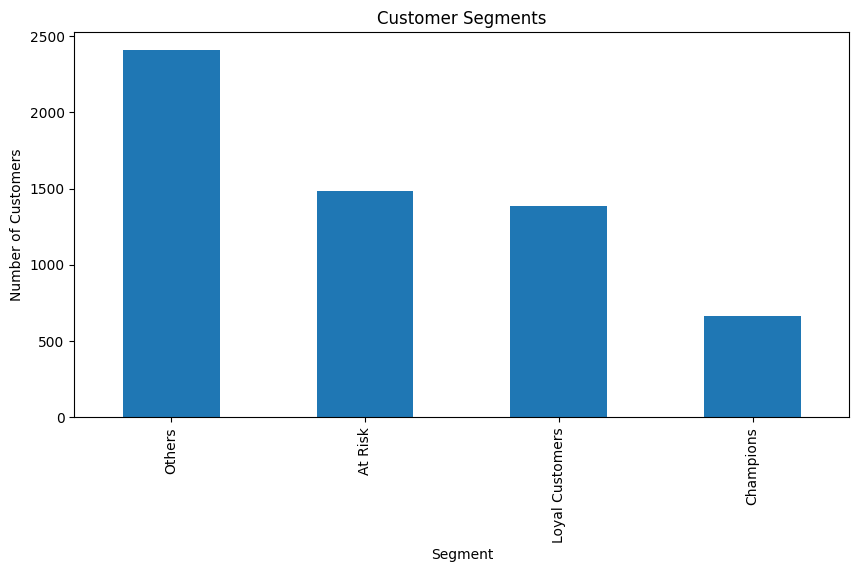

In [27]:
rfm['Segment'].value_counts().plot(kind='bar', figsize=(10,5))

import matplotlib.pyplot as plt

plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

plt.show()

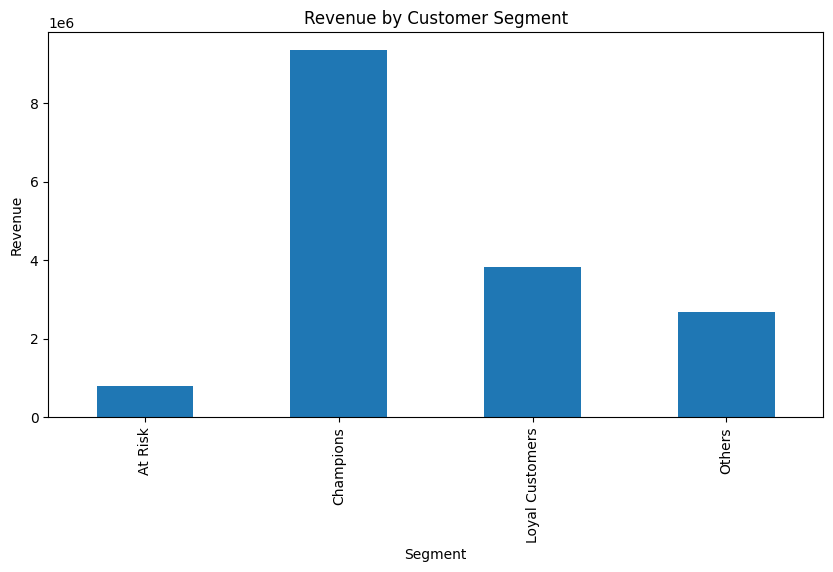

In [28]:
segment_revenue.plot(kind='bar', figsize=(10,5))

plt.title("Revenue by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Revenue")

plt.show()

In [29]:
rfm.sort_values('Monetary', ascending=False).head(10)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
Customer ID,,,,,,,,
18102.0,1,153,598215.22,4,4,4,444,Champions
14646.0,2,164,523342.07,4,4,4,444,Champions
14156.0,10,202,296564.69,4,4,4,444,Champions
14911.0,1,510,270248.53,4,4,4,444,Champions
17450.0,8,61,233579.39,4,4,4,444,Champions
13694.0,4,164,190825.52,4,4,4,444,Champions
17511.0,3,85,171885.98,4,4,4,444,Champions
12415.0,24,33,143269.29,4,4,4,444,Champions
16684.0,4,65,141502.25,4,4,4,444,Champions


In [30]:
rfm.to_csv("../output/rfm_customer_segments.csv")
